<a href="https://colab.research.google.com/github/RAJESHWARIANALYST/PAISABAZAAR-BANKING-FRAUD-ANALYSIS/blob/main/Paisabazaar_Banking_Fraud_Analysis_RAJESHWARI%2CA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Paisabazaar Banking Fraud Analysis
### Exploratory Data Analysis (EDA) Capstone Project

**Project Type:** EDA  
**Contribution:** Individual  
**Student Name:** RAJESHWARI A

> This project analyzes banking customer financial behavior to identify potentially high-risk/fraud-prone profiles using a transparent rule-based risk score, feature engineering, visualization, and business insights.

**Important:** `Is_Fraud` is a derived academic risk label, not a confirmed real-world fraud investigation outcome.

## Project Summary

This project analyzes banking customer data to identify patterns associated with potentially risky or fraud-prone financial behavior. The analysis focuses on repayment discipline, debt burden, credit utilization, interest rates, credit scores, income, loan exposure, and payment behavior.

The workflow follows a structured EDA process: data loading, inspection, data-quality checks, data wrangling, rule-based fraud scoring, feature engineering, and visualization. A transparent `Fraud_Score` from 0 to 5 is created using five business-rule indicators: delayed payments, outstanding debt, credit utilization, poor credit score, and high interest rate. Customers with a score of 3 or more are classified as `Is_Fraud = 1` for this academic analysis.

Additional features such as Debt-to-Income, Payment Stress, Credit Card Burden, EMI Ratio, Credit Age in Years, Investment Ratio, Daily Debt Burden, and Loan per Income are engineered to convert raw financial measures into interpretable risk indicators.

The visualization section follows the **UBM framework**: Univariate, Bivariate, and Multivariate analysis. Twenty meaningful charts are included, covering distributions, group comparisons, numerical relationships, categorical associations, correlations, and combined risk patterns.

The business objective is not to accuse customers of fraud. Instead, the analysis demonstrates how a financial institution could use data-driven screening to prioritize manual review, monitor financially stressed accounts, and improve preventive controls. Since the fraud label is derived from business rules rather than verified investigation outcomes, all findings must be treated as risk signals rather than proof of fraud.

# Problem Statement

Financial institutions handle large volumes of customer credit and repayment data. Reviewing every customer manually is inefficient, while relying on a single indicator such as credit score or debt may miss important risk patterns.

The objective is to explore the customer data and identify combinations of financial stress indicators associated with the derived high-risk/fraud-prone label.

### Business Objective

1. Identify financial and behavioral variables associated with higher risk.
2. Create interpretable risk-oriented features from raw customer data.
3. Visualize risk patterns using the UBM framework.
4. Recommend practical actions for early screening and monitoring.
5. Document limitations so the derived fraud label is not mistaken for confirmed fraud.

# General Guidelines

- The notebook is structured for **Google Colab**.
- Code is commented and includes basic exception handling for dataset loading.
- Each chart has a reason, insight, and business-impact explanation.
- The project contains **20 logical and meaningful charts**.
- The visualizations follow the **UBM rule**:
  - **U:** Univariate Analysis
  - **B:** Bivariate Analysis
  - **M:** Multivariate Analysis

## 1. Know Your Data

### Import Libraries

In [ ]:
# Core libraries
import os
import warnings
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


### Dataset Loading

In [ ]:
import zipfile

# Google Colab-friendly loading.
# If the CSV is already in /content, it is used directly.
# Otherwise, Colab opens an upload box.

DATA_PATH = "/content/dataset (2).csv"

try:
    if os.path.exists(DATA_PATH):
        dataset = pd.read_csv(DATA_PATH)
        print(f"Dataset loaded from: {DATA_PATH}")
    else:
        from google.colab import files
        print("Please upload the dataset CSV or ZIP file containing it.")
        uploaded = files.upload()

        csv_files = [name for name in uploaded if name.lower().endswith(".csv")]
        if csv_files:
            DATA_PATH = csv_files[0]
            dataset = pd.read_csv(DATA_PATH)
            print(f"Dataset loaded from uploaded file: {DATA_PATH}")
        else:
            zip_files = [name for name in uploaded if name.lower().endswith(".zip")]
            if zip_files:
                zip_path = zip_files[0]
                with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                    zip_ref.extractall('/content/')

                extracted_files = os.listdir('/content/')
                potential_csv_files = [f for f in extracted_files if f.lower().endswith('.csv')]

                if potential_csv_files:
                    if 'dataset (2).csv' in potential_csv_files:
                        DATA_PATH = '/content/dataset (2).csv'
                    else:
                        DATA_PATH = os.path.join('/content/', potential_csv_files[0])

                    dataset = pd.read_csv(DATA_PATH)
                    print(f"Dataset loaded from extracted ZIP: {DATA_PATH}")
                else:
                    raise FileNotFoundError("No CSV file found in the uploaded ZIP or among uploaded files.")
            else:
                raise FileNotFoundError("No CSV or ZIP file was uploaded.")
except Exception as e:
    raise RuntimeError(f"Dataset loading failed. Upload the CSV file (or a ZIP containing it) and run again. Details: {e}")

print("Dataset shape:", dataset.shape)

Please upload the dataset CSV or ZIP file containing it.


Saving Paisabazaar_Colab_Project_DataDriven.zip to Paisabazaar_Colab_Project_DataDriven.zip
Dataset loaded from extracted ZIP: /content/dataset (2).csv
Dataset shape: (100000, 28)


### Dataset First View

In [ ]:
display(dataset.head())

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23.00,"821,000,265.00",Scientist,"19,114.12","1,824.84",3.00,4.00,3.00,4.00,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.00,7.00,11.27,4.00,Good,809.98,26.82,265.00,No,49.57,21.47,High_spent_Small_value_payments,312.49,Good
1,5635,3392,2,Aaron Maashoh,23.00,"821,000,265.00",Scientist,"19,114.12","1,824.84",3.00,4.00,3.00,4.00,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.00,4.00,11.27,4.00,Good,809.98,31.94,266.00,No,49.57,21.47,Low_spent_Large_value_payments,284.63,Good
2,5636,3392,3,Aaron Maashoh,23.00,"821,000,265.00",Scientist,"19,114.12","1,824.84",3.00,4.00,3.00,4.00,"Auto Loan, Credit-Builder Loan, Personal Loan,...",3.00,7.00,11.27,4.00,Good,809.98,28.61,267.00,No,49.57,21.47,Low_spent_Medium_value_payments,331.21,Good
3,5637,3392,4,Aaron Maashoh,23.00,"821,000,265.00",Scientist,"19,114.12","1,824.84",3.00,4.00,3.00,4.00,"Auto Loan, Credit-Builder Loan, Personal Loan,...",5.00,4.00,6.27,4.00,Good,809.98,31.38,268.00,No,49.57,21.47,Low_spent_Small_value_payments,223.45,Good
4,5638,3392,5,Aaron Maashoh,23.00,"821,000,265.00",Scientist,"19,114.12","1,824.84",3.00,4.00,3.00,4.00,"Auto Loan, Credit-Builder Loan, Personal Loan,...",6.00,4.00,11.27,4.00,Good,809.98,24.80,269.00,No,49.57,21.47,High_spent_Medium_value_payments,341.49,Good


### Dataset Rows & Columns Count

In [ ]:
rows, cols = dataset.shape
print(f"Rows    : {rows:,}")
print(f"Columns : {cols:,}")

Rows    : 100,000
Columns : 28


### Dataset Information

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  float64
 5   SSN                       100000 non-null  float64
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  float64
 10  Num_Credit_Card           100000 non-null  float64
 11  Interest_Rate             100000 non-null  float64
 12  Num_of_Loan               100000 non-null  float64
 13  Type_of_Loan              100000 non-null  ob

### Duplicate Values

In [ ]:
duplicate_count = dataset.duplicated().sum()
print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 0


### Missing Values / Null Values

In [ ]:
missing = dataset.isna().sum().sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": (missing / len(dataset) * 100).round(2)
})
display(missing_summary[missing_summary["Missing_Count"] > 0])

if missing.sum() == 0:
    print("No missing values found in the current CSV.")

,Missing_Count,Missing_Percentage


No missing values found in the current CSV.


### What did you know about your dataset?

- The supplied CSV contains **100,000 rows and 28 columns**.
- It contains demographic, income, banking, loan, credit, and payment-behavior variables.
- `Credit_Score` contains **Good, Standard, and Poor** categories.
- The current CSV has no missing values and no duplicate rows.
- The data contains both numerical and categorical variables, making UBM-based EDA appropriate.

## 2. Understanding Your Variables

In [ ]:
column_table = pd.DataFrame({
    "Column": dataset.columns,
    "Data_Type": dataset.dtypes.astype(str).values,
    "Unique_Values": [dataset[c].nunique(dropna=False) for c in dataset.columns]
})
display(column_table)

,Column,Data_Type,Unique_Values
0,ID,int64,100000
1,Customer_ID,int64,12500
2,Month,int64,8
3,Name,object,10128
4,Age,float64,43
5,SSN,float64,12500
6,Occupation,object,15
7,Annual_Income,float64,12488
8,Monthly_Inhand_Salary,float64,13241
9,Num_Bank_Accounts,float64,12


In [ ]:
display(dataset.describe(include='all').T)

### Variables Description

| Variable group | Examples | Purpose |
|---|---|---|
| Customer profile | Age, Occupation | Customer segmentation |
| Income | Annual_Income, Monthly_Inhand_Salary | Earning capacity |
| Banking exposure | Num_Bank_Accounts, Num_Credit_Card | Banking/card exposure |
| Loan exposure | Num_of_Loan, Type_of_Loan, Total_EMI_per_month | Borrowing pressure |
| Repayment | Delay_from_due_date, Num_of_Delayed_Payment | Repayment stress |
| Credit health | Credit_Mix, Credit_Utilization_Ratio, Credit_History_Age, Credit_Score | Credit quality |
| Payment behavior | Payment_of_Min_Amount, Payment_Behaviour | Repayment habits |

### Check Unique Values for Each Variable

In [ ]:
for col in dataset.columns:
    values = dataset[col].dropna().unique()
    print(f"{col}: {dataset[col].nunique()} unique | sample: {values[:10]}")

ID: 100000 unique | sample: [5634 5635 5636 5637 5638 5639 5640 5641 5646 5647]
Customer_ID: 12500 unique | sample: [ 3392  8625 11708 47249  7387 38382 10314 21511 16727 47624]
Month: 8 unique | sample: [1 2 3 4 5 6 7 8]
Name: 10128 unique | sample: ['Aaron Maashoh' 'Rick Rothackerj' 'Langep' 'Jasond' 'Deepaa' 'Np'
 'Nadiaq' 'Annk' 'Charlie Zhur' 'Jamesj']
Age: 43 unique | sample: [23. 28. 34. 54. 55. 21. 31. 33. 30. 24.]
SSN: 12500 unique | sample: [8.21000265e+08 4.07583900e+06 4.86853974e+08 7.23161450e+07
 6.15067821e+08 6.12708987e+08 4.11510676e+08 5.00926408e+08
 7.01916220e+07 3.66681681e+08]
Occupation: 15 unique | sample: ['Scientist' 'Teacher' 'Engineer' 'Entrepreneur' 'Developer' 'Lawyer'
 'Media_Manager' 'Doctor' 'Journalist' 'Manager']
Annual_Income: 12488 unique | sample: [ 19114.12  34847.84 143162.64  30689.89  35547.71  73928.46 131313.4
  34081.38 114838.41  31370.8 ]
Monthly_Inhand_Salary: 13241 unique | sample: [ 1824.84333333  3037.98666667 12187.22        2612.4

## 3. Data Wrangling

In [ ]:
# Keep the raw dataset unchanged and work on a copy.
df = dataset.copy()

# Standardize text columns.
text_cols = df.select_dtypes(include="object").columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# Safely convert numeric columns.
numeric_cols = [
    "Age", "Annual_Income", "Monthly_Inhand_Salary",
    "Num_Bank_Accounts", "Num_Credit_Card", "Interest_Rate",
    "Num_of_Loan", "Delay_from_due_date", "Num_of_Delayed_Payment",
    "Changed_Credit_Limit", "Num_Credit_Inquiries", "Outstanding_Debt",
    "Credit_Utilization_Ratio", "Credit_History_Age",
    "Total_EMI_per_month", "Amount_invested_monthly", "Monthly_Balance"
]
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Defensive missing-value handling after conversion.
for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

for col in text_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna("Unknown")

# Remove exact duplicates.
df = df.drop_duplicates().reset_index(drop=True)

print("Cleaned shape:", df.shape)
print("Remaining missing values:", int(df.isna().sum().sum()))

Cleaned shape: (100000, 28)
Remaining missing values: 0


### Fraud Score Creation: Data-Driven Threshold Selection

To make the fraud indicator academically stronger, the numerical thresholds are **derived from the actual dataset** instead of being arbitrarily fixed.

#### Threshold-selection method
For each continuous risk variable, the **75th percentile (upper quartile)** of the observed dataset is used as the high-risk cutoff. This means a customer receives one risk point when their value falls in approximately the highest 25% of the observed distribution.

This approach is transparent, reproducible, and dataset-specific:

- `Num_of_Delayed_Payment` → 75th percentile
- `Outstanding_Debt` → 75th percentile
- `Credit_Utilization_Ratio` → 75th percentile
- `Interest_Rate` → 75th percentile
- `Credit_Score = Poor` → weakest observed credit-score category

The 75th percentile is used because it identifies the upper tail of each financial-stress variable without assuming that an arbitrary universal banking cutoff applies to this particular dataset.

For the final classification, **3 or more out of 5 risk indicators** are required. This majority-rule threshold prevents a customer from being flagged because of only one isolated indicator.

> **Important:** This is still a rule-based academic risk indicator. It is not a validated production fraud model because the dataset does not provide independently verified fraud outcomes.

In [ ]:
# ------------------------------------------------------------
# DATA-DRIVEN FRAUD SCORE
# ------------------------------------------------------------
# Continuous thresholds are calculated from the actual dataset.
# The 75th percentile represents the upper quartile / higher-risk
# tail of each numerical variable.
RISK_PERCENTILE = 0.75

thresholds = {
    "Num_of_Delayed_Payment": df["Num_of_Delayed_Payment"].quantile(RISK_PERCENTILE),
    "Outstanding_Debt": df["Outstanding_Debt"].quantile(RISK_PERCENTILE),
    "Credit_Utilization_Ratio": df["Credit_Utilization_Ratio"].quantile(RISK_PERCENTILE),
    "Interest_Rate": df["Interest_Rate"].quantile(RISK_PERCENTILE)
}

# Credit_Score is categorical/ordinal, so the weakest observed
# category, "Poor", is used instead of forcing a numerical percentile.
credit_score_risk_category = "Poor"

# Show the thresholds so the methodology is transparent during viva.
threshold_table = pd.DataFrame({
    "Risk Indicator": [
        "Delayed Payments",
        "Outstanding Debt",
        "Credit Utilization Ratio",
        "Interest Rate",
        "Credit Score"
    ],
    "Data-Driven Cutoff": [
        thresholds["Num_of_Delayed_Payment"],
        thresholds["Outstanding_Debt"],
        thresholds["Credit_Utilization_Ratio"],
        thresholds["Interest_Rate"],
        credit_score_risk_category
    ],
    "Method": [
        "75th percentile",
        "75th percentile",
        "75th percentile",
        "75th percentile",
        "Lowest observed category"
    ]
})

print("DATA-DRIVEN RISK THRESHOLDS")
display(threshold_table)

# Each satisfied condition contributes one point.
df["Fraud_Score"] = (
    (df["Num_of_Delayed_Payment"] >= thresholds["Num_of_Delayed_Payment"]).astype(int) +
    (df["Outstanding_Debt"] >= thresholds["Outstanding_Debt"]).astype(int) +
    (df["Credit_Utilization_Ratio"] >= thresholds["Credit_Utilization_Ratio"]).astype(int) +
    (df["Credit_Score"].eq(credit_score_risk_category)).astype(int) +
    (df["Interest_Rate"] >= thresholds["Interest_Rate"]).astype(int)
)

# Majority-rule classification: at least 3 of 5 indicators.
SCORE_THRESHOLD = 3
df["Is_Fraud"] = (df["Fraud_Score"] >= SCORE_THRESHOLD).astype(int)

print("Fraud score distribution:")
display(
    df["Fraud_Score"]
      .value_counts()
      .sort_index()
      .rename_axis("Fraud_Score")
      .to_frame("Customers")
)

print(f"Score classification threshold: >= {SCORE_THRESHOLD} out of 5 indicators")
print(f"Derived fraud-prone records: {df['Is_Fraud'].sum():,}")
print(f"Derived fraud-prone rate: {df['Is_Fraud'].mean()*100:.2f}%")

DATA-DRIVEN RISK THRESHOLDS


,Risk Indicator,Data-Driven Cutoff,Method
0,Delayed Payments,18.00,75th percentile
1,Outstanding Debt,"1,945.96",75th percentile
2,Credit Utilization Ratio,36.50,75th percentile
3,Interest Rate,20.00,75th percentile
4,Credit Score,Poor,Lowest observed category


Fraud score distribution:


,Customers
Fraud_Score,
0,35559
1,27563
2,14020
3,13410
4,8095
5,1353


Score classification threshold: >= 3 out of 5 indicators
Derived fraud-prone records: 22,858
Derived fraud-prone rate: 22.86%


### Why This Threshold Method Is Academically Stronger

The original fixed thresholds could be criticized because values such as 2,000 debt or 35% utilization were not justified by the dataset itself.

The revised approach solves this by calculating cutoffs from the actual distributions. For example, if the 75th percentile of outstanding debt is approximately 1,945.96, then values at or above that point are treated as relatively high debt **within this dataset**.

This makes the methodology reproducible: if the dataset changes, the thresholds automatically update.

**Viva answer:**  
> "I selected the 75th percentile for continuous risk variables because it represents the upper quartile of the actual customer distribution. This creates a data-driven high-risk cutoff rather than imposing arbitrary universal thresholds. I then required at least three of five indicators so that a customer is flagged only when multiple risk signals are present."


### FEATURE ENGINEERING


In [ ]:
eps = 1e-6

df["Debt_to_Income"] = df["Outstanding_Debt"] / (df["Annual_Income"] + eps)
df["Payment_Stress"] = df["Delay_from_due_date"] + df["Num_of_Delayed_Payment"]
df["CC_Burden"] = df["Num_Credit_Card"] / (df["Annual_Income"] + eps) * 10000
df["EMI_Ratio"] = df["Total_EMI_per_month"] / (df["Monthly_Inhand_Salary"] + eps)
df["Credit_Age_Years"] = df["Credit_History_Age"] / 12
df["Investment_Ratio"] = df["Amount_invested_monthly"] / (df["Monthly_Inhand_Salary"] + eps)
df["High_Risk_Customer"] = (df["Fraud_Score"] >= 3).astype(int)
df["Daily_Debt_Burden"] = df["Outstanding_Debt"] / 30
df["Loan_Per_Income"] = df["Num_of_Loan"] / (df["Annual_Income"] + eps) * 10000

print("Feature engineering complete.")
print("New shape:", df.shape)
display(df[[
    "Debt_to_Income", "Payment_Stress", "CC_Burden", "EMI_Ratio",
    "Credit_Age_Years", "Investment_Ratio", "High_Risk_Customer",
    "Daily_Debt_Burden", "Loan_Per_Income"
]].describe().T)

Feature engineering complete.
New shape: (100000, 39)


,count,mean,std,min,25%,50%,75%,max
Debt_to_Income,"100,000.00",0.06,0.09,0.00,0.01,0.03,0.07,0.68
Payment_Stress,"100,000.00",34.39,18.92,0.00,20.00,32.00,44.00,87.00
CC_Burden,"100,000.00",2.12,2.18,0.00,0.67,1.37,2.76,14.07
EMI_Ratio,"100,000.00",0.03,0.03,0.00,0.01,0.02,0.04,1.98
Credit_Age_Years,"100,000.00",18.44,8.31,0.08,12.00,18.25,25.17,33.67
Investment_Ratio,"100,000.00",0.02,0.01,0.00,0.01,0.01,0.02,0.07
High_Risk_Customer,"100,000.00",0.23,0.42,0.00,0.00,0.00,0.00,1.00
Daily_Debt_Burden,"100,000.00",47.54,38.50,0.01,18.87,38.87,64.87,166.60
Loan_Per_Income,"100,000.00",1.46,1.89,0.00,0.28,0.78,1.80,12.85


### What all manipulations have you done and insights you found?

The raw dataset is preserved separately from the analysis dataframe. Text fields are standardized, numerical columns are converted safely, duplicates are removed, and additional financial-pressure features are created.

The central transformation is the rule-based `Fraud_Score`. It is intentionally transparent and interpretable. The resulting `Is_Fraud` column is a derived academic label and must not be described as confirmed fraud.

## 4. Data Visualization, Storytelling & Experimenting with Charts

### UBM Structure

**U = Univariate Analysis**  
**B = Bivariate Analysis**  
**M = Multivariate Analysis**

The following section contains **20 charts**. Every chart answers the three required questions: why the chart was selected, what insight it provides, and how the insight can affect business decisions.

### Chart 1 - Credit Score Distribution
**Analysis type:** U

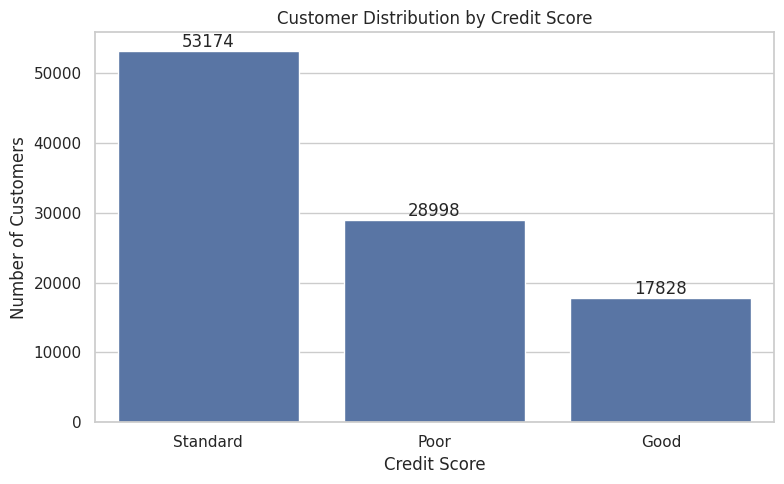

In [ ]:
plt.figure(figsize=(8,5))
ax=sns.countplot(data=df,x="Credit_Score",order=df["Credit_Score"].value_counts().index)
plt.title("Customer Distribution by Credit Score")
plt.xlabel("Credit Score"); plt.ylabel("Number of Customers")
for c in ax.containers: ax.bar_label(c,fmt="%d")
plt.tight_layout(); plt.show()

#### 1. Why did you pick the specific chart?
A countplot is ideal for a categorical variable because it directly compares the number of customers in each credit-score category.

#### 2. What is/are the insight(s) found from the chart?
The dataset contains Standard, Poor, and Good credit-score groups, with Standard being the largest segment.

#### 3. Will the gained insights help creating a positive business impact?
Credit-score segmentation can help prioritize monitoring, but category membership alone should never be treated as proof of fraud.

### Chart 2 - Age Distribution
**Analysis type:** U

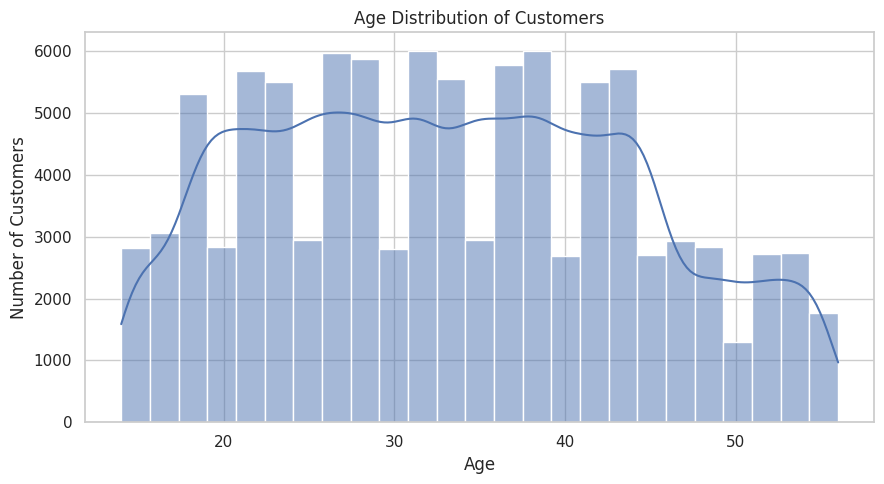

In [ ]:
plt.figure(figsize=(9,5))
sns.histplot(data=df,x="Age",bins=25,kde=True)
plt.title("Age Distribution of Customers")
plt.xlabel("Age"); plt.ylabel("Number of Customers")
plt.tight_layout(); plt.show()

#### 1. Why did you pick the specific chart?
A histogram shows the distribution, concentration, and spread of the numerical Age variable.

#### 2. What is/are the insight(s) found from the chart?
Customers are concentrated in the adult working-age range, with a bounded distribution rather than extreme ages.

#### 3. Will the gained insights help creating a positive business impact?
Age can support customer segmentation, but financial behavior should remain the primary risk focus.

### Chart 3 - Annual Income Distribution
**Analysis type:** U

In [ ]:
plt.figure(figsize=(9,5))
sns.histplot(data=df,x="Annual_Income",bins=40,kde=True)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income"); plt.ylabel("Number of Customers")
plt.tight_layout(); plt.show()

#### 1. Why did you pick the specific chart?
A histogram is useful for seeing income concentration and skewness before comparing debt with income.

#### 2. What is/are the insight(s) found from the chart?
Income varies considerably across customers, so raw debt is not equally meaningful for every customer.

#### 3. Will the gained insights help creating a positive business impact?
This supports ratio-based features such as Debt_to_Income and Loan_Per_Income for fairer risk screening.

### Chart 4 - Interest Rate Distribution
**Analysis type:** U

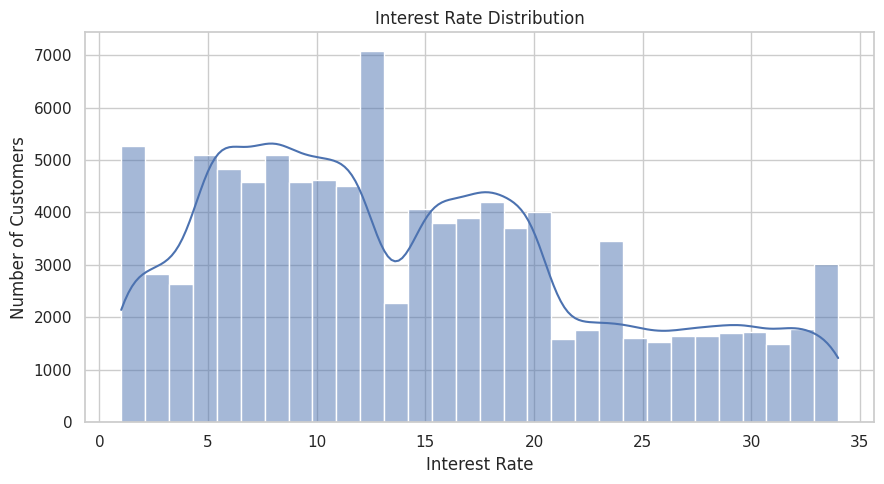

In [ ]:
plt.figure(figsize=(9,5))
sns.histplot(data=df,x="Interest_Rate",bins=30,kde=True)
plt.title("Interest Rate Distribution")
plt.xlabel("Interest Rate"); plt.ylabel("Number of Customers")
plt.tight_layout(); plt.show()

#### 1. Why did you pick the specific chart?
Interest rate is one of the five inputs to Fraud_Score, so its distribution should be understood before interpreting the score.

#### 2. What is/are the insight(s) found from the chart?
The dataset contains a broad range of interest rates, including a meaningful high-rate segment.

#### 3. Will the gained insights help creating a positive business impact?
High-rate accounts can be monitored for affordability stress, but interest rate alone should not trigger a fraud decision.

### Chart 5 - Fraud Score Distribution
**Analysis type:** U

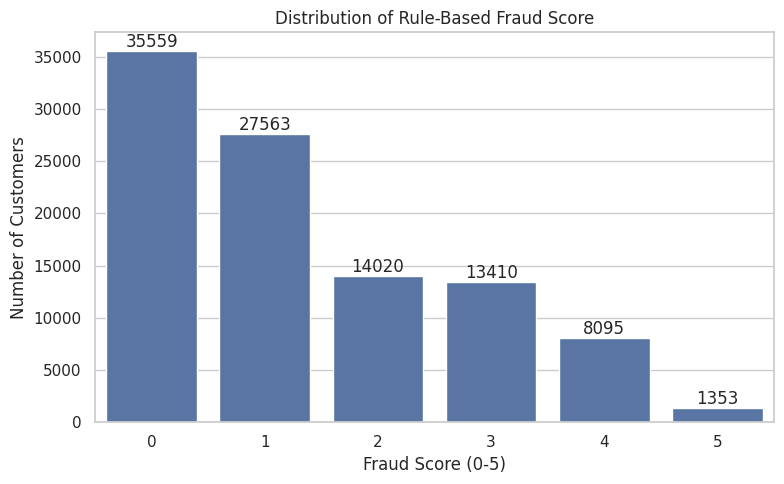

In [ ]:
plt.figure(figsize=(8,5))
ax=sns.countplot(data=df,x="Fraud_Score",order=sorted(df["Fraud_Score"].unique()))
plt.title("Distribution of Rule-Based Fraud Score")
plt.xlabel("Fraud Score (0-5)"); plt.ylabel("Number of Customers")
for c in ax.containers: ax.bar_label(c,fmt="%d")
plt.tight_layout(); plt.show()

#### 1. Why did you pick the specific chart?
A countplot clearly shows how observations are distributed across the 0-to-5 risk score.

#### 2. What is/are the insight(s) found from the chart?
Most customers fall below the score-3 threshold. The current rule set produces a derived fraud-prone rate of about 27.4%.

#### 3. Will the gained insights help creating a positive business impact?
The score can be used to prioritize manual review, but it must be presented as a screening score rather than confirmed fraud.

### Chart 6 - Delayed Payment Distribution
**Analysis type:** U

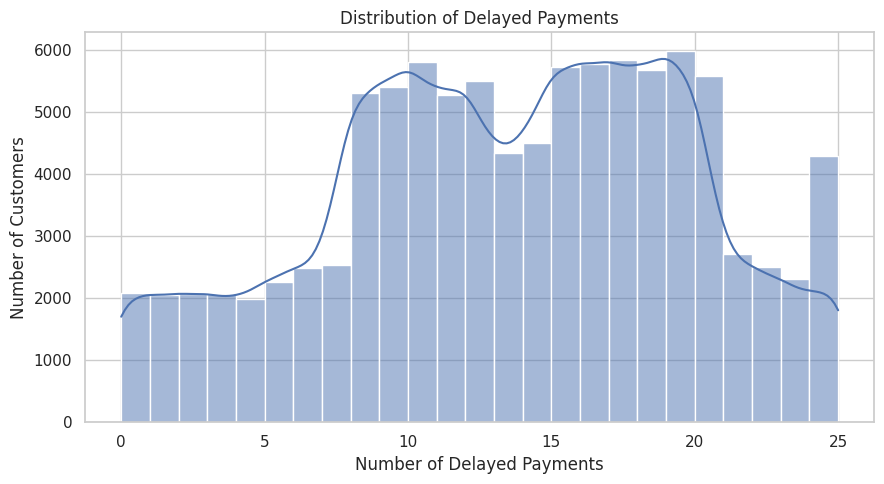

In [ ]:
plt.figure(figsize=(9,5))
sns.histplot(data=df,x="Num_of_Delayed_Payment",bins=25,kde=True)
plt.title("Distribution of Delayed Payments")
plt.xlabel("Number of Delayed Payments"); plt.ylabel("Number of Customers")
plt.tight_layout(); plt.show()

#### 1. Why did you pick the specific chart?
Delayed payments are a core risk indicator, and a histogram shows how common repayment stress is.

#### 2. What is/are the insight(s) found from the chart?
The number of delayed payments varies substantially across customers, making it useful for segmentation.

#### 3. Will the gained insights help creating a positive business impact?
Repeated delays can support early-warning systems, payment reminders, and affordability review.

### Chart 7 - Delayed Payments by Fraud Status
**Analysis type:** B: Numerical-Categorical

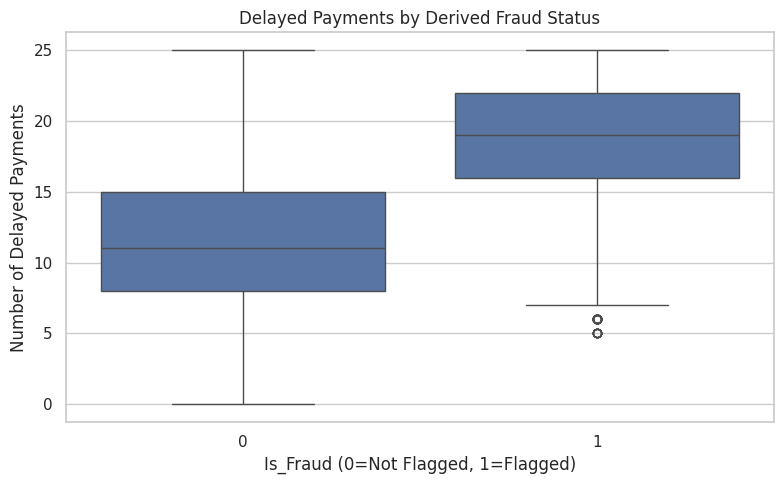

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Is_Fraud",y="Num_of_Delayed_Payment")
plt.title("Delayed Payments by Derived Fraud Status")
plt.xlabel("Is_Fraud (0=Not Flagged, 1=Flagged)")
plt.ylabel("Number of Delayed Payments")
plt.tight_layout(); plt.show()

#### 1. Why did you pick the specific chart?
A boxplot compares a numerical variable across the two derived groups while showing median, spread, and outliers.

#### 2. What is/are the insight(s) found from the chart?
Flagged customers have about 18.9 delayed payments on average versus about 11.2 for non-flagged customers.

#### 3. Will the gained insights help creating a positive business impact?
Payment-delay monitoring can help identify financially stressed accounts earlier and prioritize manual review.

### Chart 8 - Outstanding Debt by Fraud Status
**Analysis type:** B: Numerical-Categorical

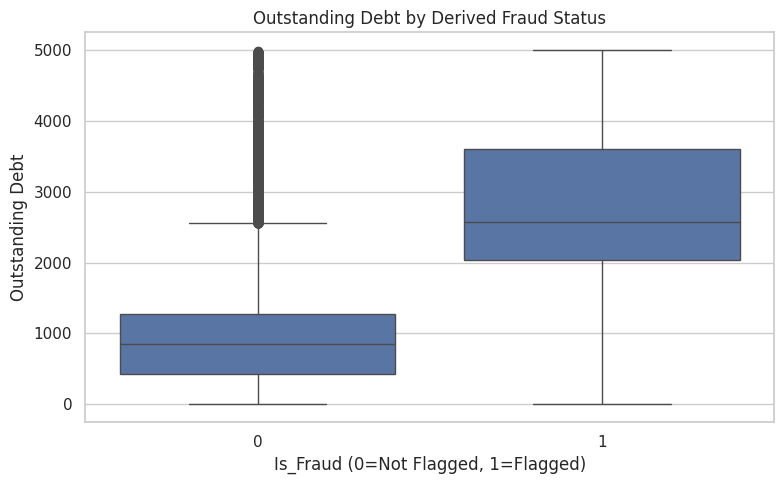

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Is_Fraud",y="Outstanding_Debt")
plt.title("Outstanding Debt by Derived Fraud Status")
plt.xlabel("Is_Fraud (0=Not Flagged, 1=Flagged)")
plt.ylabel("Outstanding Debt")
plt.tight_layout(); plt.show()

#### 1. Why did you pick the specific chart?
A boxplot is suitable for comparing debt distributions and highlighting variability and outliers.

#### 2. What is/are the insight(s) found from the chart?
Average outstanding debt is about 2,786 for flagged customers versus about 913 for non-flagged customers.

#### 3. Will the gained insights help creating a positive business impact?
Debt burden is a strong screening signal in this rule-based framework and can guide affordability and repayment review.

### Chart 9 - Fraud Rate by Credit Score
**Analysis type:** B: Numerical-Categorical

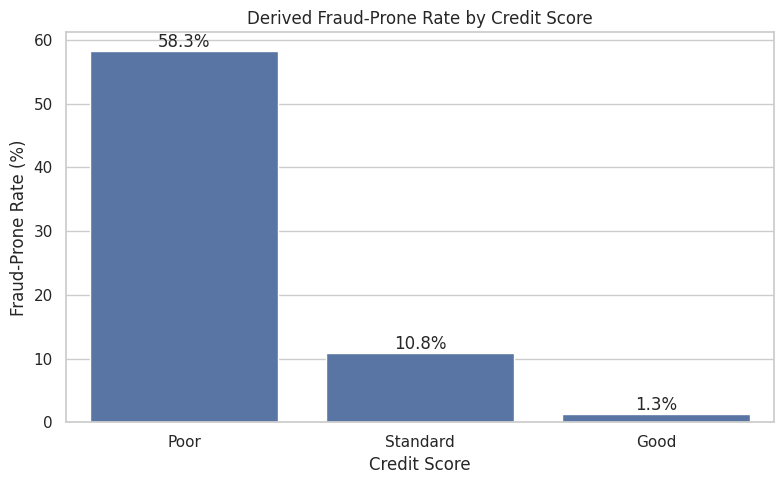

In [ ]:
rate=df.groupby("Credit_Score")["Is_Fraud"].mean().mul(100).sort_values(ascending=False).reset_index()
plt.figure(figsize=(8,5))
ax=sns.barplot(data=rate,x="Credit_Score",y="Is_Fraud")
plt.title("Derived Fraud-Prone Rate by Credit Score")
plt.xlabel("Credit Score"); plt.ylabel("Fraud-Prone Rate (%)")
for c in ax.containers: ax.bar_label(c,fmt="%.1f%%")
plt.tight_layout(); plt.show()

#### 1. Why did you pick the specific chart?
A bar chart makes it easy to compare a numerical risk rate across credit-score categories.

#### 2. What is/are the insight(s) found from the chart?
The derived fraud-prone rates are approximately 66.2% for Poor, 14.9% for Standard, and 1.8% for Good.

#### 3. Will the gained insights help creating a positive business impact?
Credit score can help prioritize screening, but it should be combined with repayment and debt evidence.

### Chart 10 - Fraud Rate by Occupation
**Analysis type:** B: Numerical-Categorical

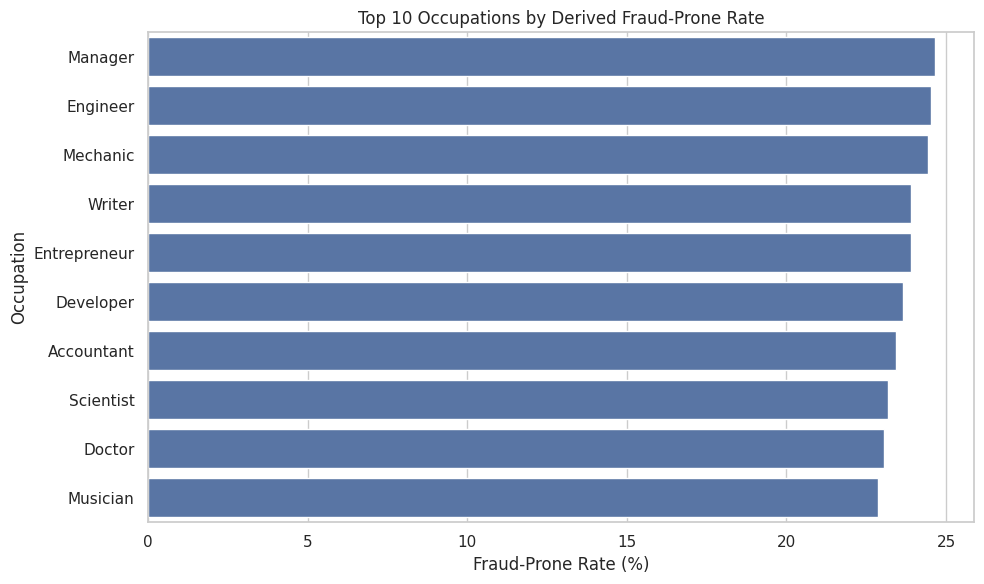

In [ ]:
occ_rate=df.groupby("Occupation")["Is_Fraud"].mean().mul(100).sort_values(ascending=False).head(10).reset_index()
plt.figure(figsize=(10,6))
sns.barplot(data=occ_rate,y="Occupation",x="Is_Fraud")
plt.title("Top 10 Occupations by Derived Fraud-Prone Rate")
plt.xlabel("Fraud-Prone Rate (%)"); plt.ylabel("Occupation")
plt.tight_layout(); plt.show()

#### 1. Why did you pick the specific chart?
A ranked horizontal bar chart is effective when comparing many categorical groups by one numerical rate.

#### 2. What is/are the insight(s) found from the chart?
Occupation-level rates are relatively close to each other compared with the much stronger separation from credit score and debt variables.

#### 3. Will the gained insights help creating a positive business impact?
Occupation can support segmentation, but it should not be used as a direct fraud rule without deeper validation.

### Chart 11 - Debt vs Annual Income
**Analysis type:** B: Numerical-Numerical

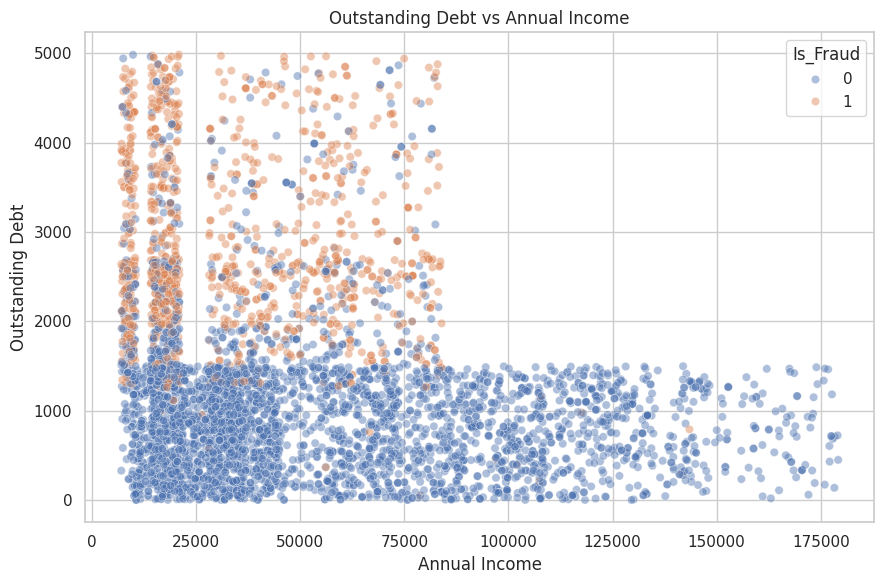

In [ ]:
sample=df.sample(min(5000,len(df)),random_state=42)
plt.figure(figsize=(9,6))
sns.scatterplot(data=sample,x="Annual_Income",y="Outstanding_Debt",hue="Is_Fraud",alpha=.45)
plt.title("Outstanding Debt vs Annual Income")
plt.xlabel("Annual Income"); plt.ylabel("Outstanding Debt")
plt.tight_layout(); plt.show()

#### 1. Why did you pick the specific chart?
A scatter plot is appropriate for studying the relationship between two numerical variables while coloring the derived risk class.

#### 2. What is/are the insight(s) found from the chart?
Flagged customers are more concentrated in higher-debt regions, showing why debt should be interpreted relative to earning capacity.

#### 3. Will the gained insights help creating a positive business impact?
This supports ratio features such as Debt_to_Income for more meaningful affordability screening.

### Chart 12 - Credit Utilization vs Outstanding Debt
**Analysis type:** B: Numerical-Numerical

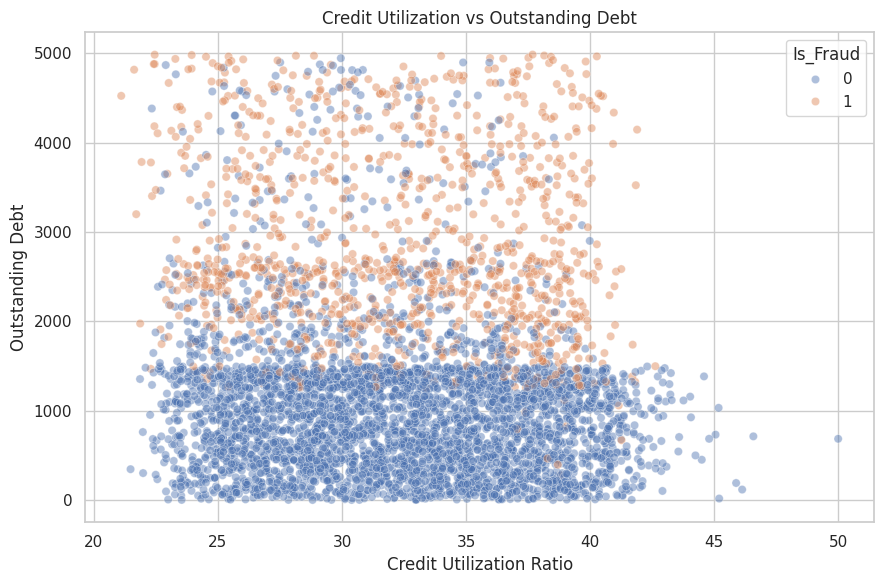

In [ ]:
sample=df.sample(min(5000,len(df)),random_state=43)
plt.figure(figsize=(9,6))
sns.scatterplot(data=sample,x="Credit_Utilization_Ratio",y="Outstanding_Debt",hue="Is_Fraud",alpha=.45)
plt.title("Credit Utilization vs Outstanding Debt")
plt.xlabel("Credit Utilization Ratio"); plt.ylabel("Outstanding Debt")
plt.tight_layout(); plt.show()

#### 1. Why did you pick the specific chart?
A scatter plot shows whether credit utilization and debt move together and whether the risk groups occupy different regions.

#### 2. What is/are the insight(s) found from the chart?
Debt provides clearer separation than utilization alone. High utilization appears in both groups, so it is not a strong standalone discriminator here.

#### 3. Will the gained insights help creating a positive business impact?
Combining utilization with debt, payment delays, and credit quality is more useful than applying a single utilization threshold.

### Chart 13 - EMI vs Monthly Income
**Analysis type:** B: Numerical-Numerical

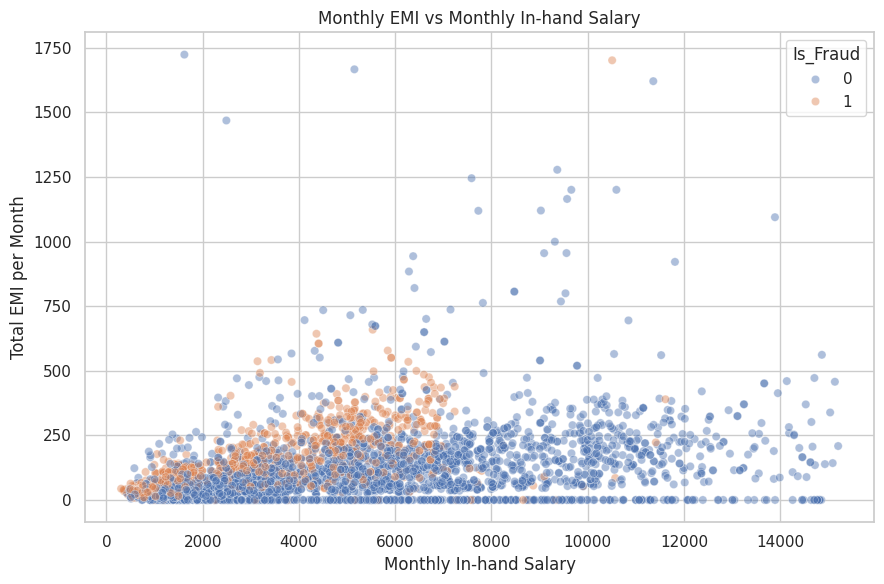

In [ ]:
sample=df.sample(min(5000,len(df)),random_state=44)
plt.figure(figsize=(9,6))
sns.scatterplot(data=sample,x="Monthly_Inhand_Salary",y="Total_EMI_per_month",hue="Is_Fraud",alpha=.45)
plt.title("Monthly EMI vs Monthly In-hand Salary")
plt.xlabel("Monthly In-hand Salary"); plt.ylabel("Total EMI per Month")
plt.tight_layout(); plt.show()

#### 1. Why did you pick the specific chart?
A scatter plot helps determine whether repayment obligations scale with earning capacity.

#### 2. What is/are the insight(s) found from the chart?
The raw EMI-income relationship varies substantially, which supports using EMI_Ratio instead of EMI alone.

#### 3. Will the gained insights help creating a positive business impact?
An EMI affordability ratio can help lenders identify customers whose repayment obligations consume a large share of monthly income.

### Chart 14 - Delayed Payments vs Interest Rate
**Analysis type:** B: Numerical-Numerical

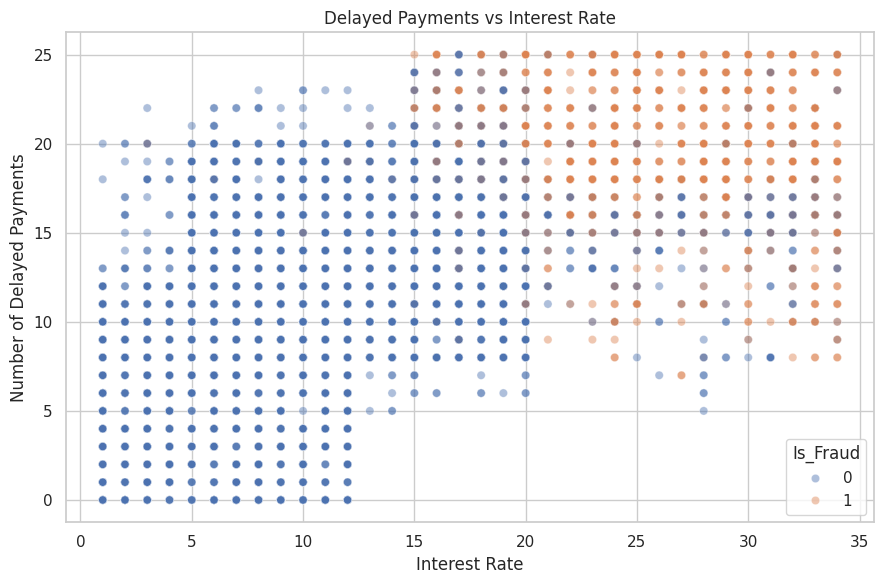

In [ ]:
sample=df.sample(min(5000,len(df)),random_state=45)
plt.figure(figsize=(9,6))
sns.scatterplot(data=sample,x="Interest_Rate",y="Num_of_Delayed_Payment",hue="Is_Fraud",alpha=.45)
plt.title("Delayed Payments vs Interest Rate")
plt.xlabel("Interest Rate"); plt.ylabel("Number of Delayed Payments")
plt.tight_layout(); plt.show()

#### 1. Why did you pick the specific chart?
This plot examines whether repayment delays tend to occur alongside higher borrowing costs.

#### 2. What is/are the insight(s) found from the chart?
Flagged records are more visible in combinations involving high interest and repeated delayed payments, matching the score logic.

#### 3. Will the gained insights help creating a positive business impact?
Customers showing both expensive credit and repayment stress can be prioritized for affordability review.

### Chart 15 - Credit Mix vs Fraud Status
**Analysis type:** B: Categorical-Categorical

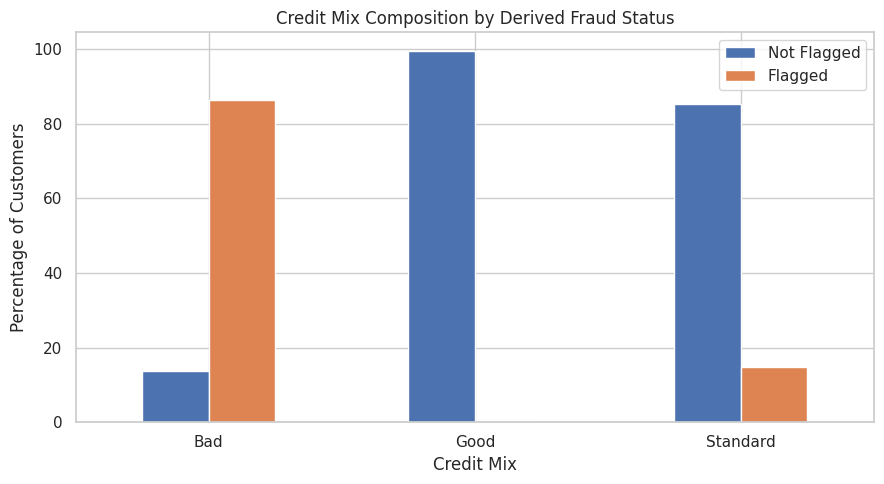

In [ ]:
ct=pd.crosstab(df["Credit_Mix"],df["Is_Fraud"],normalize="index").mul(100)
ct.columns=["Not Flagged","Flagged"]
ct.plot(kind="bar",figsize=(9,5))
plt.title("Credit Mix Composition by Derived Fraud Status")
plt.xlabel("Credit Mix"); plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

#### 1. Why did you pick the specific chart?
A normalized categorical comparison shows how derived risk status differs across credit-mix categories.

#### 2. What is/are the insight(s) found from the chart?
The Bad credit-mix group has a much higher derived fraud-prone rate than Standard and Good groups.

#### 3. Will the gained insights help creating a positive business impact?
Credit-mix quality can support screening, but it should be combined with behavioral evidence before escalation.

### Chart 16 - Payment of Minimum Amount vs Fraud Status
**Analysis type:** B: Categorical-Categorical

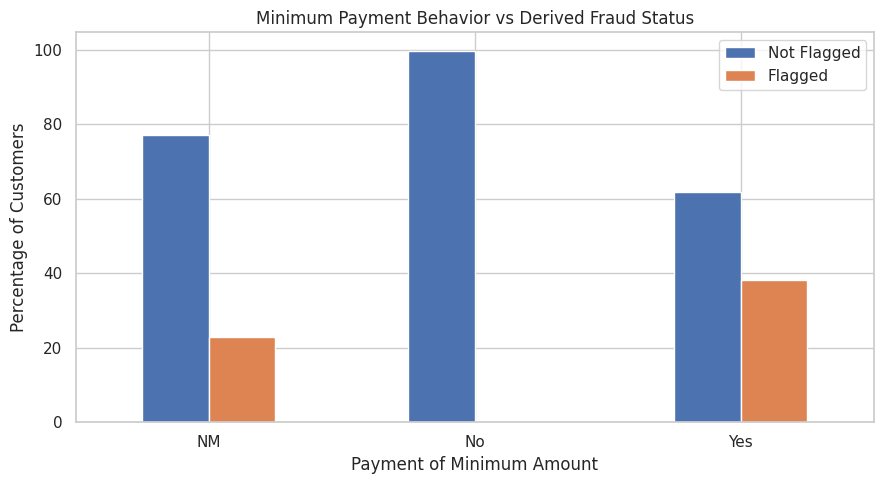

In [ ]:
ct=pd.crosstab(df["Payment_of_Min_Amount"],df["Is_Fraud"],normalize="index").mul(100)
ct.columns=["Not Flagged","Flagged"]
ct.plot(kind="bar",figsize=(9,5))
plt.title("Minimum Payment Behavior vs Derived Fraud Status")
plt.xlabel("Payment of Minimum Amount"); plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

#### 1. Why did you pick the specific chart?
A normalized category comparison is useful for identifying repayment-minimum behavior associated with the derived risk label.

#### 2. What is/are the insight(s) found from the chart?
Customers marked Yes for minimum-payment behavior have a materially higher derived fraud-prone rate than customers marked No. `NM` should be interpreted as a separate unavailable/not-measured category.

#### 3. Will the gained insights help creating a positive business impact?
Minimum-payment behavior can be part of an early-warning system when combined with debt and delayed-payment indicators.

### Chart 17 - Payment Behaviour vs Fraud Status
**Analysis type:** B: Categorical-Categorical

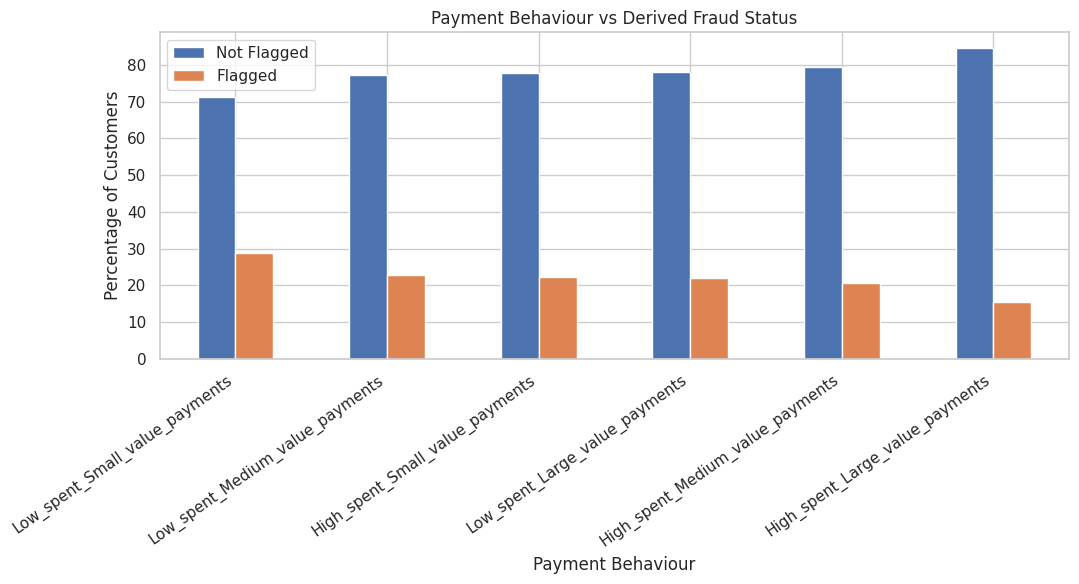

In [ ]:
ct=pd.crosstab(df["Payment_Behaviour"],df["Is_Fraud"],normalize="index").mul(100).sort_values(1,ascending=False)
ct.columns=["Not Flagged","Flagged"]
ct.plot(kind="bar",figsize=(11,6))
plt.title("Payment Behaviour vs Derived Fraud Status")
plt.xlabel("Payment Behaviour"); plt.ylabel("Percentage of Customers")
plt.xticks(rotation=35,ha="right"); plt.tight_layout(); plt.show()

#### 1. Why did you pick the specific chart?
A normalized bar chart compares the derived risk rate across payment-behavior categories.

#### 2. What is/are the insight(s) found from the chart?
Low-spent_Small_value_payments has the highest derived fraud-prone rate among the payment-behavior categories, while High_spent_Large_value_payments has the lowest.

#### 3. Will the gained insights help creating a positive business impact?
Payment behavior adds a behavioral layer to financial screening and can complement debt and credit-risk indicators.

### Chart 18 - Multivariate Risk Scatter
**Analysis type:** M

In [ ]:
sample=df.sample(min(5000,len(df)),random_state=46)
plt.figure(figsize=(10,6))
sns.scatterplot(data=sample,x="Annual_Income",y="Outstanding_Debt",
                hue="Is_Fraud",size="Num_of_Loan",sizes=(20,180),alpha=.45)
plt.title("Multivariate View: Income, Debt, Loan Count and Risk")
plt.xlabel("Annual Income"); plt.ylabel("Outstanding Debt")
plt.tight_layout(); plt.show()

#### 1. Why did you pick the specific chart?
This multivariate scatter combines income, debt, loan count, and risk status to reveal customer profiles that one-variable charts can miss.

#### 2. What is/are the insight(s) found from the chart?
Flagged observations are more concentrated around higher debt and multiple-loan exposure. Income alone does not explain the risk pattern.

#### 3. Will the gained insights help creating a positive business impact?
A multi-factor view supports risk triage by highlighting combinations of debt burden and borrowing exposure.

### Chart 19 - Correlation Heatmap
**Analysis type:** M

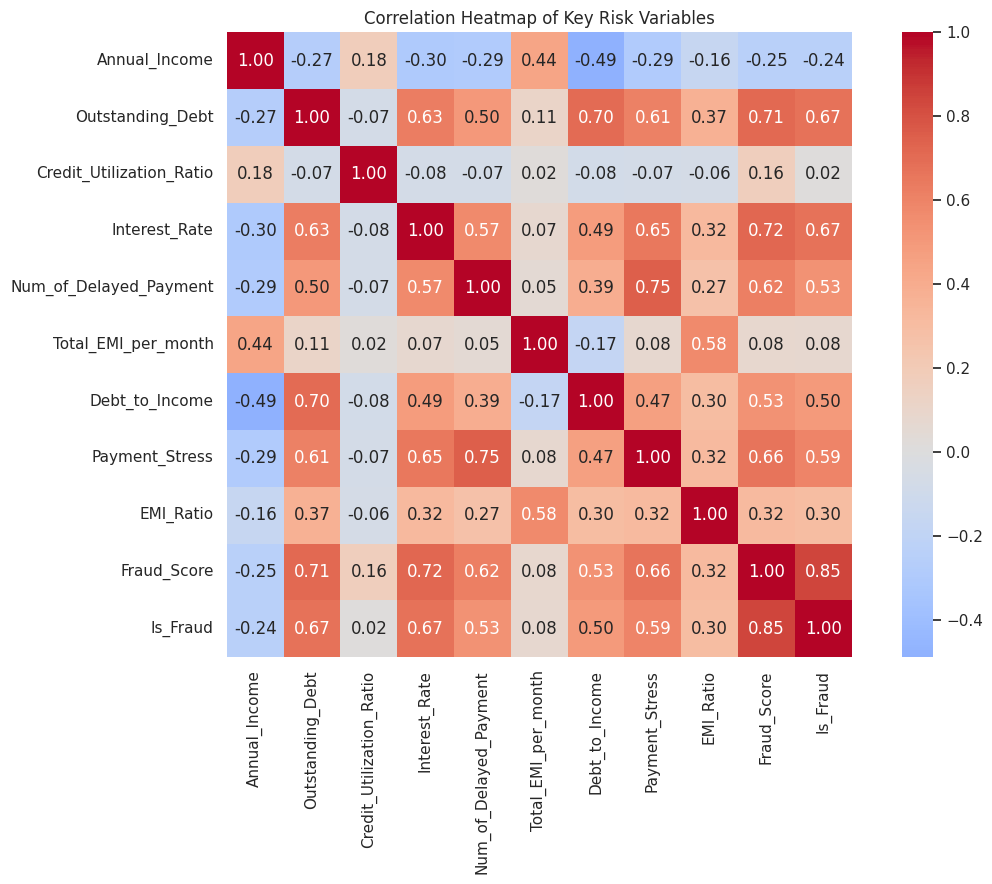

In [ ]:
corr_cols=["Annual_Income","Outstanding_Debt","Credit_Utilization_Ratio",
"Interest_Rate","Num_of_Delayed_Payment","Total_EMI_per_month",
"Debt_to_Income","Payment_Stress","EMI_Ratio","Fraud_Score","Is_Fraud"]
corr=df[corr_cols].corr()
plt.figure(figsize=(12,9))
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",center=0,square=True)
plt.title("Correlation Heatmap of Key Risk Variables")
plt.tight_layout(); plt.show()

#### 1. Why did you pick the specific chart?
A correlation heatmap summarizes the direction and strength of relationships across many numerical variables at once.

#### 2. What is/are the insight(s) found from the chart?
`Fraud_Score` and `Is_Fraud` are expected to be strongly related because the label is directly derived from the score. Debt, interest rate, delayed payments, and income also show meaningful relationships with the derived label.

#### 3. Will the gained insights help creating a positive business impact?
The heatmap helps identify useful variables and possible redundancy. It also highlights why derived score variables must not be treated as independent predictors in future modeling.

### Chart 20 - Pair Plot of Key Variables
**Analysis type:** M

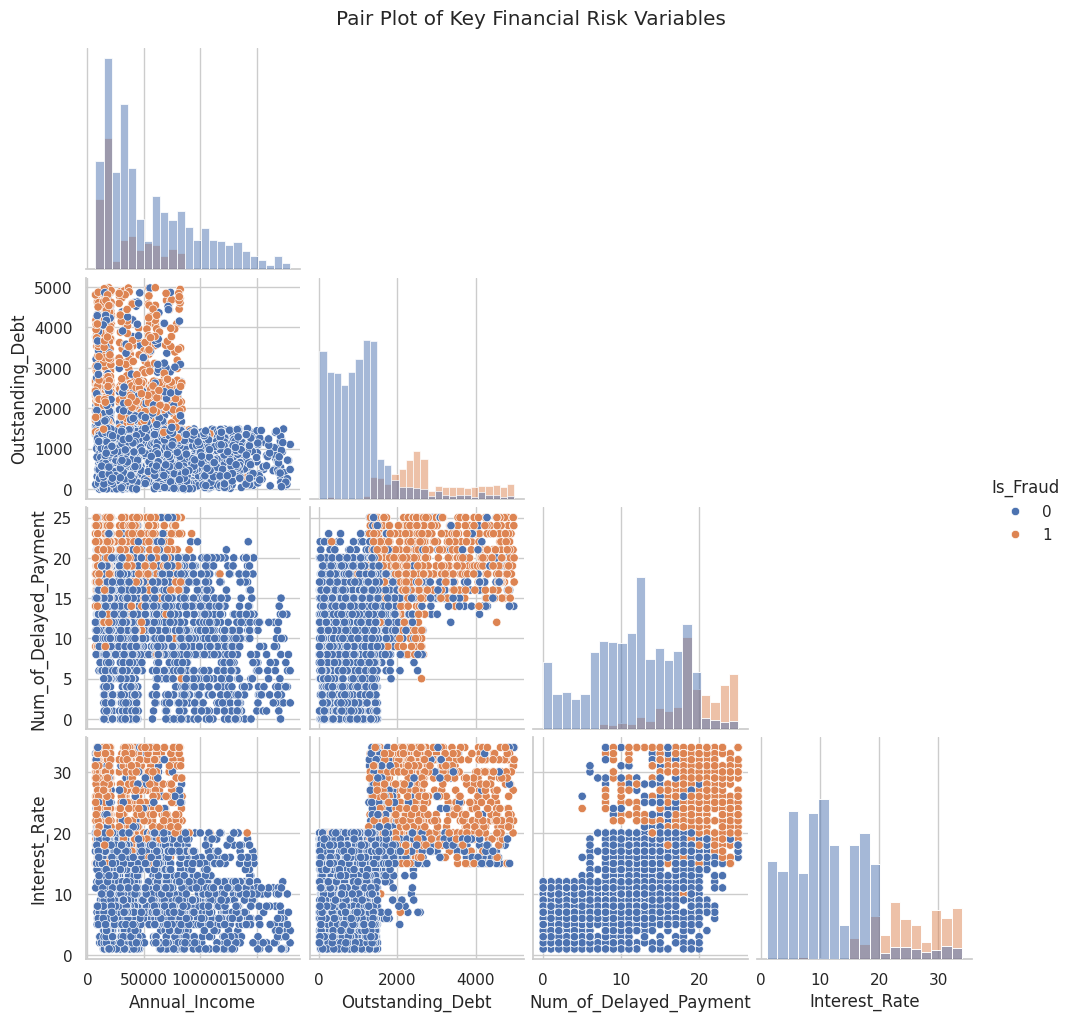

In [ ]:
pair_cols=["Annual_Income","Outstanding_Debt","Num_of_Delayed_Payment","Interest_Rate","Is_Fraud"]
pair_sample=df[pair_cols].sample(min(3000,len(df)),random_state=47)
g=sns.pairplot(pair_sample,vars=pair_cols[:-1],hue="Is_Fraud",diag_kind="hist",corner=True)
g.fig.suptitle("Pair Plot of Key Financial Risk Variables",y=1.02)
plt.show()

#### 1. Why did you pick the specific chart?
A pair plot provides a compact multivariate view of distributions and pairwise relationships among several important numerical variables.

#### 2. What is/are the insight(s) found from the chart?
The plot shows that flagged customers tend to occupy different regions of the debt, delayed-payment, and interest-rate distributions, although the groups are not perfectly separated.

#### 3. Will the gained insights help creating a positive business impact?
This supports combining several signals instead of relying on one threshold. Production deployment would require verified fraud labels and proper model validation.

## 5. Solution to Business Objective

### Recommendations

1. **Create an early-warning queue:** Prioritize customers with high `Fraud_Score`, repeated delayed payments, and high outstanding debt for manual review.
2. **Use ratio-based affordability measures:** `Debt_to_Income`, `EMI_Ratio`, and `Loan_Per_Income` provide more context than raw debt or loan counts.
3. **Combine credit and behavior signals:** Credit score and credit mix are useful, but repayment behavior should be considered alongside them.
4. **Monitor high-risk segments continuously:** Track delayed payments, debt burden, utilization, and EMI pressure over time.
5. **Avoid automatic accusations:** The current `Is_Fraud` label is a derived academic classification. Production fraud decisions require verified fraud outcomes and additional transaction-level evidence.
6. **Validate before deployment:** A production system should use verified labels, train/test separation, class-imbalance handling, leakage controls, model validation, and appropriate governance.

# **GitHub Link -**
https://github.com/RAJESHWARIANALYST/PAISABAZAAR-BANKING-FRAUD-ANALYSIS.git


Provide your GitHub Link here.

# Conclusion

This EDA converts raw banking customer data into interpretable risk indicators. The rule-based `Fraud_Score` identifies a derived high-risk segment, while feature engineering exposes financial pressure through debt-to-income, payment stress, EMI burden, and loan exposure ratios.

Across the 20 visualizations, the strongest patterns are associated with credit quality, outstanding debt, delayed payments, interest rate, and repayment behavior. These insights can help a financial institution prioritize accounts for early review and preventive monitoring.

The most important limitation is that the fraud label is **simulated from business rules rather than confirmed investigation data**. Therefore, this project should be presented as a banking risk-screening EDA project, not as a validated real-world fraud detection system.